In [1]:
import pickle
import json
from pathlib import Path

import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

import sys
sys.path.append('../../')
sys.path.append('../')

from src import plot_utils as pu

['/home/mila/c/cornforj/eg_rnns/mod_cog/analysis/arial.ttf']
/home/mila/c/cornforj/eg_rnns/mod_cog/analysis/arial.ttf
/home/mila/c/cornforj/eg_rnns/mod_cog/analysis/arial.ttf


## Prerequisites

Run `script_small_world_analysis.py` first.

This writes `small_world_directed.json` to `/network/projects/_groups/linclab_users/eg/modcog/analysis/clustering`.

In [2]:
eg_c = "#f05039" # orangey red
gd_c = "#1f449c" # blue

In [3]:
savedir = Path("/network/projects/_groups/linclab_users/eg/modcog/analysis/clustering")
with open(savedir/"small_world_directed.json", "r") as f:
    small_world_directed = json.load(f)

In [6]:
small_world_directed

{'eg': {'0.99': [2.633969882028945,
   2.6364500451068964,
   2.654979284823091,
   2.614357848181311,
   2.561713885003229],
  '0.98': [1.718656920321182,
   1.7045519986799385,
   1.717843596237624,
   1.6906353509780128,
   1.6826240140928754],
  '0.97': [1.4294321562127696,
   1.4178040724132785,
   1.4145150523016488,
   1.4088880959585721,
   1.3994603079920103],
  '0.96': [1.3058961083207208,
   1.2940759211260509,
   1.2907098835475557,
   1.2862881172190261,
   1.2914390572455914],
  '0.95': [1.2383458724398018,
   1.2286948829869673,
   1.2243645252652828,
   1.226604178358922,
   1.2288054466462335]},
 'gd': {'0.99': [1.498563066864385,
   1.5078859688354598,
   1.5063225098779196,
   1.5896781196760672,
   1.4444940358794593],
  '0.98': [1.3242065757319563,
   1.318728694934312,
   1.3499269714298257,
   1.3541681675471038,
   1.300811757565143],
  '0.97': [1.2515445114873598,
   1.2403199376029586,
   1.2573748930038557,
   1.2631525032321715,
   1.2233385943552437],
  '0.

In [7]:
eg_df = pd.DataFrame(small_world_directed["eg"])
eg_df = eg_df[sorted(eg_df.columns)]
eg_df


,0.95,0.96,0.97,0.98,0.99
0,1.238346,1.305896,1.429432,1.718657,2.633970
1,1.228695,1.294076,1.417804,1.704552,2.636450
2,1.224365,1.290710,1.414515,1.717844,2.654979
3,1.226604,1.286288,1.408888,1.690635,2.614358
4,1.228805,1.291439,1.399460,1.682624,2.561714


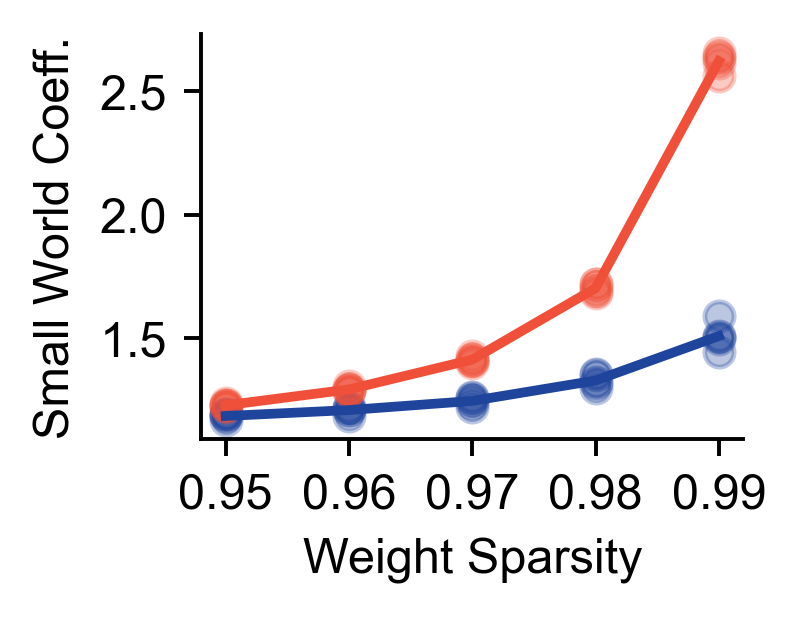

In [9]:
eg_df = pd.DataFrame(small_world_directed["eg"])
eg_df = eg_df[sorted(eg_df.columns)]

gd_df = pd.DataFrame(small_world_directed["gd"])
gd_df = gd_df[sorted(gd_df.columns)]

x_vals = eg_df.columns

fig = plt.figure(figsize=(2.,1.5), dpi=350)

# GD
for i, row in gd_df.iterrows():
    plt.scatter(x_vals, row.values, color=gd_c, alpha=0.3)  # alpha makes it faint

# EG
for i, row in eg_df.iterrows():
    plt.scatter(x_vals, row.values, color=eg_c, alpha=0.3)  # alpha makes it faint

mean_vals = eg_df.mean(axis=0)
plt.plot(x_vals, mean_vals, color=eg_c, linewidth=2, label="EG")
mean_vals = gd_df.mean(axis=0)
plt.plot(x_vals, mean_vals, color=gd_c, linewidth=2, label="GD")

sns.despine()
plt.ylabel("Small World Coeff.")
plt.xlabel("Weight Sparsity")
# plt.title("Directed")
# plt.legend()


fig_path = Path("../figs/fig_sw_analysis/")
plt.savefig(fig_path/f"directed_swc.png" )
plt.savefig(fig_path/f"directed_swc.pdf",bbox_inches="tight", transparent=True )